# Beam with varying EI and q #

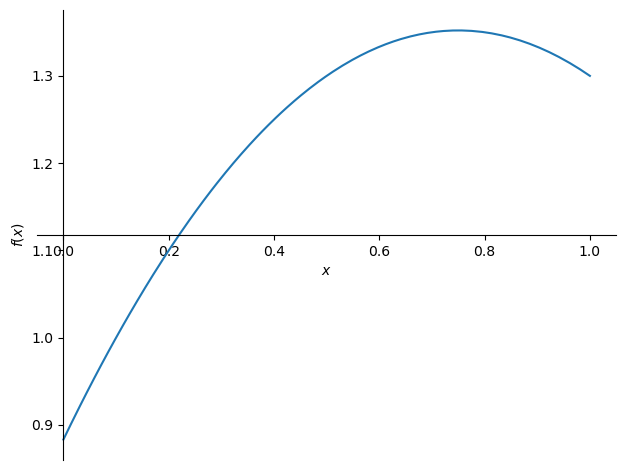

Eq((5/4 - 8333*x/5000)*Derivative(w(x), x) + (-8333*x**2/10000 + 5*x/4 + 883333/1000000)*Derivative(w(x), (x, 2)), 0)

C1 + C2*log(x - 6250/8333 + sqrt(11267063889)/83330) - C2*log(x - sqrt(11267063889)/83330 - 6250/8333)

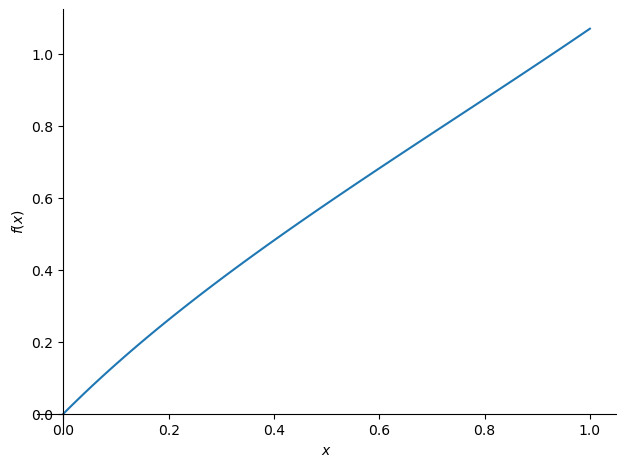

In [1]:
import sympy as sp
import numpy as np

w = sp.symbols('w', cls=sp.Function)
C1, C2 = sp.symbols('C1 C2')
x = sp.symbols('x')
L = 1

X_c = [0.1, 0.5, 0.9]

# f = 0
# for x_c in X_c:
#     f = sp.exp(-(x - x_c)**2) + f

# E = sp.simplify(f)
# E = sp.nsimplify(1)
# E = sp.nsimplify(sp.sin(x*(2*sp.pi)) + 2)
E = sp.nsimplify(-0.8333*x**2 + 1.25*x + 0.883333)
# E = sp.simplify(sp.exp(-x**2))
# E = sp.simplify(sp.exp(-(x-0.3)**2) + sp.exp(-(x-0.6)**2))
# E = sp.exp(-(x-0.3)**2) + sp.exp(-(x-0.6)**2)
# E = sp.exp(-(x-0.3)**2)
# q = sp.nsimplify(-500*w(x)+10+400*sp.diff(w(x),x,2))
# q = sp.nsimplify(500)
# q = sp.nsimplify( sp.DiracDelta(x-L))
F = 1.

sp.plotting.plot(E,(x,0,L))

diffeq = sp.Eq(sp.diff(E*sp.diff(w(x),x,1),x,1), 0)
display(diffeq)

w = sp.dsolve(diffeq)
w = w.rhs
display(w)

eps = sp.diff(w, x)
# kappa = sp.diff(phi, x)
# M = EI * kappa
# V = sp.diff(M, x)

eq1 = sp.Eq(w.subs(x , 0) , 0)
eq2 = sp.Eq(eps.subs(x , L) , F)
# eq2 = sp.Eq(phi.subs(x , 0) , 0)

sol = sp.solve((eq1,eq2),
               (C1 ,C2))
w_sol = w.subs(sol)
# M_sol = M.subs(sol)

sp.plot(w_sol,(x,0,L))
# sp.plot(M_sol,(x,0,L));

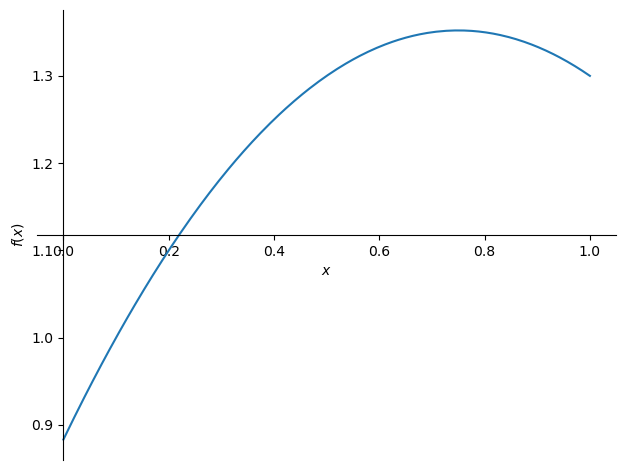

Eq((-8333*x**2/10000 + 5*x/4 + 883333/1000000)*Derivative(w(x), x), 1.0)

C1 - 0.471047416116385*log(1.0*x - 2.02383807323453) + 0.471047416116385*log(1.0*x + 0.523778070834437)

ValueError: The same variable should be used in all univariate expressions being plotted.

In [44]:
import sympy as sp
import numpy as np

w = sp.symbols('w', cls=sp.Function)
C1, C2 = sp.symbols('C1 C2')
x = sp.symbols('x')
L = 1

X_c = [0.1, 0.5, 0.9]

# f = 0
# for x_c in X_c:
#     f = sp.exp(-(x - x_c)**2) + f

E = sp.nsimplify(-0.8333*x**2 + 1.25*x + 0.883333)
F = 1.

sp.plotting.plot(E,(x,0,L))

diffeq = sp.Eq(E*sp.diff(w(x),x,1), F)
display(diffeq)

w = sp.dsolve(diffeq)
w = w.rhs
display(w)

eps = sp.diff(w, x)
# kappa = sp.diff(phi, x)
# M = EI * kappa
# V = sp.diff(M, x)

# eq1 = sp.Eq(w.subs(x , 0) , 0)
# eq2 = sp.Eq(eps.subs(x , L) , F)
# eq2 = sp.Eq(phi.subs(x , 0) , 0)

sol = sp.solve((eq2),
               (C1))
w_sol = w.subs(sol)
# M_sol = M.subs(sol)

sp.plot(w_sol,(x,0,L))
# sp.plot(M_sol,(x,0,L));

In [13]:
def chebyshev_expansion(f, N):
    x = sp.symbols('x')
    # Transform x in [0, 1] to x' in [-1, 1]
    xp = 2 * x - 1

    # Create Chebyshev polynomials T_n(x')
    T = [sp.chebyshevt(n, xp) for n in range(N+1)]

    # Define the integration variable on the transformed interval
    x_transformed = sp.Symbol('x_transformed')
    f_transformed = f.subs(x, (x_transformed + 1) / 2)

    # Calculate coefficients for the expansion
    c = []
    for n in range(N+1):
        # Substitute x' back to x_transformed for integration
        integrand = f_transformed * T[n].subs(xp, x_transformed) * sp.sqrt(1 - x_transformed**2)
        # Adjust the integral limits for the weighting function
        cn = sp.integrate(integrand, (x_transformed, -1, 1))
        if n == 0:
            cn *= 1/sp.pi
        else:
            cn *= 2/sp.pi
        c.append(cn)

    # Construct the polynomial expansion
    chebyshev_expansion = sum(c[n] * T[n] for n in range(N+1))
    return chebyshev_expansion

# Example function to expand
f = sp.exp(x)  # e^x defined on [0, 1]

# Compute expansion to degree 3
expansion = chebyshev_expansion(f, 3)
print(sp.simplify(expansion))

(2*(2*x - 1)*Integral(x_transformed*sqrt(-(x_transformed - 1)*(x_transformed + 1))*exp(x_transformed/2), (x_transformed, -1, 1)) + 2*(2*(2*x - 1)**2 - 1)*(-Integral(sqrt(-(x_transformed - 1)*(x_transformed + 1))*exp(x_transformed/2), (x_transformed, -1, 1)) + 2*Integral(x_transformed**2*sqrt(-(x_transformed - 1)*(x_transformed + 1))*exp(x_transformed/2), (x_transformed, -1, 1))) - 2*(-6*x + 4*(2*x - 1)**3 + 3)*(6*x*Integral(sqrt(-(x_transformed - 1)*(x_transformed + 1))*exp(x_transformed/2), (x_transformed, -1, 1)) - 3*Integral(sqrt(-(x_transformed - 1)*(x_transformed + 1))*exp(x_transformed/2), (x_transformed, -1, 1)) - 4*Integral(x_transformed**3*sqrt(-(x_transformed - 1)*(x_transformed + 1))*exp(x_transformed/2), (x_transformed, -1, 1))) + Integral(sqrt(-(x_transformed - 1)*(x_transformed + 1))*exp(x_transformed/2), (x_transformed, -1, 1)))*exp(1/2)/pi


/tmp/ipykernel_7679/2531627395.py:23: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  integral, error = integrate.quad(integrand, -1, 1)


Coefficients of the Chebyshev expansion: [ 3.33331400e-01 -1.13254650e+00  5.86104224e-01 -1.44796162e-01
  2.08078591e-01  3.41743140e-01 -3.19911407e-01 -7.07574071e-02
  6.49352765e-01  6.72538613e-03 -2.44875256e-01 -3.82776944e-04
 -4.01380643e-01  1.47271423e-05 -1.69119054e-02 -4.11361952e-07
  4.85164335e-01  8.79187094e-09 -4.33218116e-01 -1.36314826e-10
  2.08456244e-01  1.66610559e-12 -6.79796169e-02  1.85312702e-12
  1.65036149e-02 -5.40735586e-12 -3.14451536e-03 -8.55334260e-12
  4.86773652e-04 -9.28084590e-13 -6.27564960e-05 -1.67695501e-12
  6.86619999e-06 -3.12269900e-12 -6.47070766e-07 -5.97814609e-12
  5.31860327e-08 -1.17862896e-11 -3.78317669e-09  2.32815896e-10
  4.36190878e-11]


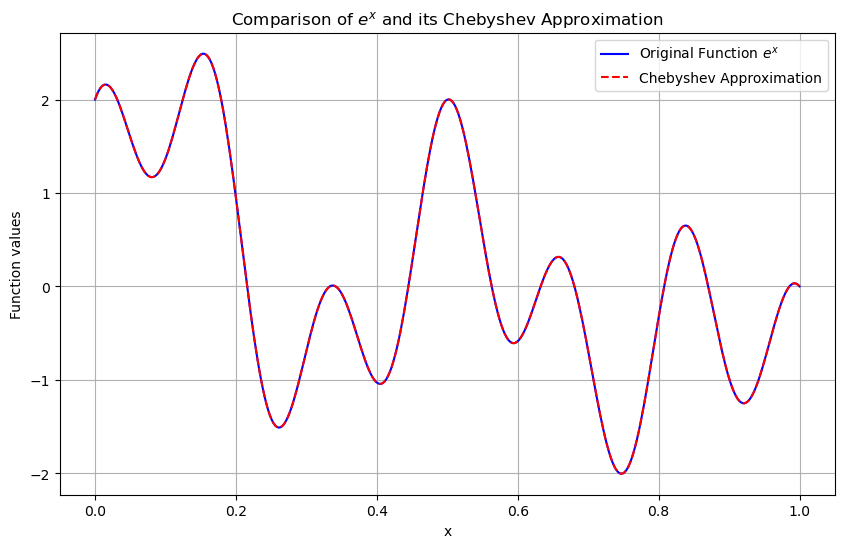

In [36]:
import numpy as np
import scipy.integrate as integrate
from numpy.polynomial.chebyshev import Chebyshev, chebval

def compute_chebyshev_coefficients(func, degree, a, b):
    # Map function to [-1, 1]
    def mapped_func(x):
        # Scale x from [-1, 1] to [a, b]
        return func((x + 1) * (b - a) / 2 + a)

    # Initialize coefficients
    coeffs = np.zeros(degree + 1)
    
    # Integrate to find each coefficient
    for n in range(degree + 1):
        # Chebyshev polynomial of the first kind
        Tn = Chebyshev.basis(n)
        
        # Define the integrand as the product of the mapped function and the nth Chebyshev polynomial
        integrand = lambda x: mapped_func(x) * Tn(x) / np.sqrt(1 - x**2)
        
        # Numerically integrate to find the nth coefficient
        integral, error = integrate.quad(integrand, -1, 1)
        
        # Factor adjustment based on the orthogonality relation
        if n == 0:
            coeffs[n] = integral / np.pi
        else:
            coeffs[n] = integral * 2 / np.pi
    
    return coeffs

def my_sin(x):
    # return 0.5*np.sin(1.2*np.pi*x) * x**2 + 0.5
    return np.sin(2.0*np.pi*x) + np.cos(3.0*np.pi*x) + np.sin(5.0*np.pi*x) + np.cos(12*np.pi*x)
    # return x - 0.5
    # return np.exp(x)
# Define the original function f(x) = exp(x) over [0, 1]
# func = np.exp
func = my_sin

# Number of coefficients (degree of the polynomial)
degree = 40
# degree = 1

# Compute coefficients
coeffs = compute_chebyshev_coefficients(func, degree, 0, 1)

# Print coefficients
print("Coefficients of the Chebyshev expansion:", coeffs)

# Optionally, evaluate the Chebyshev polynomial at points
x_values = np.linspace(0, 1, 400)
# Convert x_values to [-1, 1]
x_transformed = 2 * x_values - 1
# Evaluate the polynomial
approx_values = chebval(x_transformed, coeffs)

# Plotting, if needed
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(x_values, func(x_values), label='Original Function $e^x$', color='blue')
plt.plot(x_values, approx_values, label='Chebyshev Approximation', linestyle='--', color='red')
plt.title('Comparison of $e^x$ and its Chebyshev Approximation')
plt.xlabel('x')
plt.ylabel('Function values')
plt.legend()
plt.grid(True)
plt.show()


[-0.83333333  1.25        0.88333333]


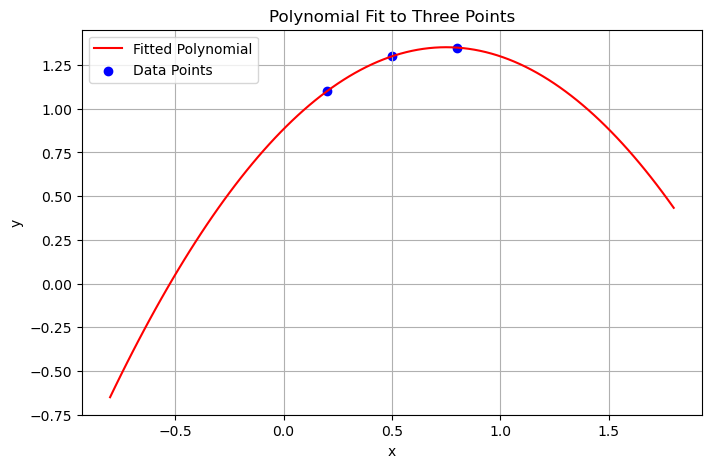

In [37]:
x = np.array([0.2, 0.5, 0.8])
y = np.array([1.1, 1.3, 1.35])

# Fit a polynomial of degree 2 (quadratic)
coefficients = np.polyfit(x, y, 2)

print(coefficients)

# Create a polynomial function using the coefficients
p = np.poly1d(coefficients)

# Generate x values for plotting the polynomial
x_line = np.linspace(min(x) - 1, max(x) + 1, 100)
y_line = p(x_line)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(x_line, y_line, label='Fitted Polynomial', color='red')
plt.scatter(x, y, color='blue', label='Data Points')
plt.title('Polynomial Fit to Three Points')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

In [218]:
from scipy.special import eval_chebyt

# Parameters for the Gaussian Random Field
mean = 0
std = 1
lengthscale = 0.5
a, b = -1, 1

# def x_tr(x):
#     # Scale x from [-1, 1] to [a, b]
#     return ((x + 1) * (b - a) / 2 + a)
def x_tr(x):
    return (b - a) * x + a
        
# Define the squared exponential kernel function
def squared_exponential_kernel(x, y, sigma=std, l=lengthscale):
    return sigma**2 * np.exp(-((x - y)**2) / (2 * l**2))

def weight(x):
    return 1 / np.sqrt(1 - x**2)

# Number of Chebyshev polynomials
N = 8

# Compute the coefficients for the Chebyshev polynomials
def compute_coefficients(n, m):
        
    def integrand(x, y):
        # Evaluate the n-th and m-th Chebyshev polynomial at x
        T_n = eval_chebyt(n, x_tr(x))
        T_m = eval_chebyt(m, x_tr(y))
        # Integral of the kernel and the n-th Chebyshev polynomial
        return squared_exponential_kernel(x_tr(x), x_tr(y)) * T_n * T_m * weight(x_tr(x)) * weight(x_tr(y))

    # We use numerical double integration over the interval [0, 1] for both x and y
    result, error = integrate.dblquad(integrand, 0, 1, 0, 1)
    # print(f"  value: {result:.4e}; error: {error:.4e}")
    return result

# Calculate coefficients
coefficients = np.zeros((N+1,N+1))
for i in range(N+1):
    for j in range(i,N+1):
        print(f"Computing coefficient ({i},{j})")

        # all products of even and odd polynomials are 0
        if (i%2==1) != (j%2==1):
            continue
            
        result = compute_coefficients(i,j)

        # normalize coefficients 
        if i==0:
            result = result * 2 / np.pi
        else:
            result = result * 4 / np.pi

        if j==0:
            result = result * 2 / np.pi
        else:
            result = result * 4 / np.pi
            
        coefficients[i,j] = coefficients[j,i] = result
        

# Display the coefficients
# print("Chebyshev coefficients:\n", coefficients)

Computing coefficient (0,0)
Computing coefficient (0,1)
Computing coefficient (0,2)
Computing coefficient (0,3)
Computing coefficient (0,4)
Computing coefficient (0,5)
Computing coefficient (0,6)
Computing coefficient (0,7)
Computing coefficient (0,8)
Computing coefficient (1,1)
Computing coefficient (1,2)
Computing coefficient (1,3)
Computing coefficient (1,4)
Computing coefficient (1,5)
Computing coefficient (1,6)
Computing coefficient (1,7)
Computing coefficient (1,8)
Computing coefficient (2,2)
Computing coefficient (2,3)
Computing coefficient (2,4)
Computing coefficient (2,5)
Computing coefficient (2,6)
Computing coefficient (2,7)
Computing coefficient (2,8)
Computing coefficient (3,3)
Computing coefficient (3,4)
Computing coefficient (3,5)
Computing coefficient (3,6)
Computing coefficient (3,7)
Computing coefficient (3,8)
Computing coefficient (4,4)
Computing coefficient (4,5)
Computing coefficient (4,6)
Computing coefficient (4,7)
Computing coefficient (4,8)
Computing coefficien

In [291]:
from scipy.special import eval_chebyt

# Parameters for the Gaussian Random Field
mean = 0
std = 1
lengthscale = 0.5
a, b = -1, 1

# def x_tr(x):
#     # Scale x from [-1, 1] to [a, b]
#     return ((x + 1) * (b - a) / 2 + a)
def x_tr(x):
    return (b - a) * x + a
        
# Define the squared exponential kernel function
def squared_exponential_kernel(x, y, sigma=std, l=lengthscale):
    return sigma**2 * np.exp(-((x - y)**2) / (2 * l**2))

def weight(x):
    return 1 / np.sqrt(1 - x**2)

# Number of Chebyshev polynomials
N = 3

# Compute the coefficients for the Chebyshev polynomials
def compute_coefficients(kernel, degree, interval):
        
    def integrand(x, y, n, m):
        # Evaluate the n-th and m-th Chebyshev polynomial at x
        T_n = eval_chebyt(n, x_tr(x))
        T_m = eval_chebyt(m, x_tr(y))
        # Integral of the kernel and the n-th Chebyshev polynomial
        return kernel(x_tr(x), x_tr(y)) * T_n * T_m * weight(x_tr(x)) * weight(x_tr(y))

    
    # Calculate coefficients
    coefficients = np.zeros((degree+1,degree+1))
    for i in range(degree+1):
        for j in range(i,degree+1):
            print(f"Computing coefficient ({i},{j})")
    
            # all products of even and odd polynomials are 0
            if (i%2==1) != (j%2==1):
                continue
                
            # result = compute_coefficients(i,j)
            result, _ = integrate.dblquad(lambda x, y: integrand(x, y, i, j),
                                          interval[0], interval[1], interval[0], interval[1])
    
            # normalize coefficients 
            if i==0:
                result = result * 2 / np.pi
            else:
                result = result * 4 / np.pi
    
            if j==0:
                result = result * 2 / np.pi
            else:
                result = result * 4 / np.pi
                
            coefficients[i,j] = coefficients[j,i] = result
    
    return coefficients

coefficients = compute_coefficients(squared_exponential_kernel, N, (0,1))

Computing coefficient (0,0)
Computing coefficient (0,1)
Computing coefficient (0,2)
Computing coefficient (0,3)
Computing coefficient (1,1)


/home/leon/anaconda3/envs/pdmp/lib/python3.11/site-packages/scipy/integrate/_quadpack_py.py:1272: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


Computing coefficient (1,2)
Computing coefficient (1,3)
Computing coefficient (2,2)
Computing coefficient (2,3)
Computing coefficient (3,3)


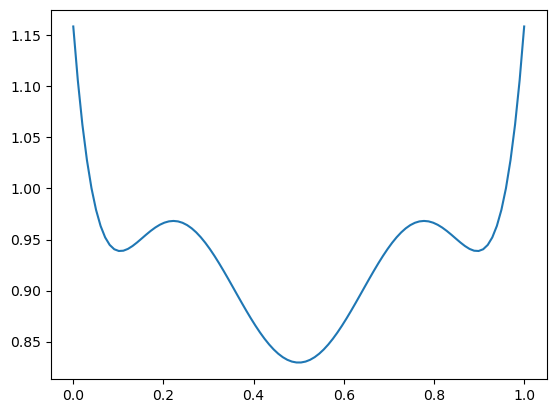

In [292]:
x = np.linspace(0,1,100)
x_transformed = 2 * x - 1
Phi = np.array([eval_chebyt(i, x_transformed) for i in range(N+1)])
cov = Phi.T @ coefficients @ Phi

fig, ax = plt.subplots()
# ax.plot(x, np.sqrt(np.diag(cov)))
ax.plot(x, np.diag(cov))

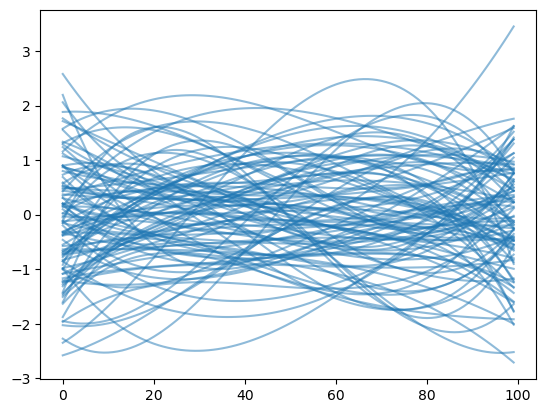

In [293]:
rng = np.random.default_rng(0)

x = np.linspace(0,1,100)
x_transformed = 2 * x - 1
Phi = np.array([eval_chebyt(i, x_transformed) for i in range(N+1)])

fig, ax = plt.subplots()
n_samples = 100

for i in range(n_samples):
    y = Phi.T @ rng.multivariate_normal(np.zeros(coefficients.shape[0]), coefficients)
    ax.plot(y, c='C0', alpha=0.5)

[ 0.28456946  1.58987387 -0.94553655 -0.4376357 ]


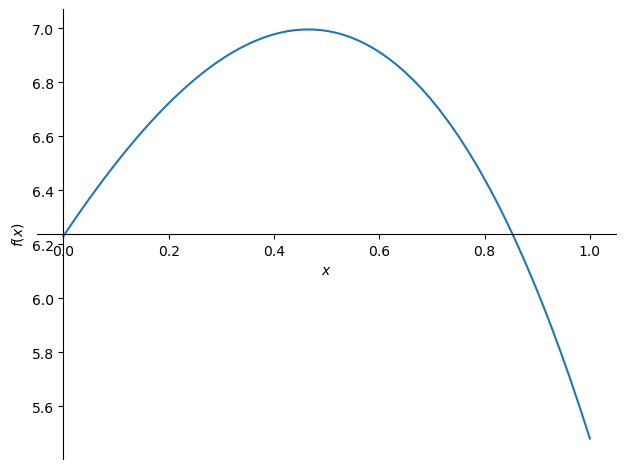

Eq((-44*x**3/25 - 19*x**2/10 + 291*x/100 + 623/100)*Derivative(w(x), x), 1.0)

PolynomialDivisionFailed: couldn't reduce degree in a polynomial division algorithm when dividing [-6.67912960000002e+52*_t**2 + 9.29280000000003e+34*_t, -1.63951392000001e+53*_t**2 + 3.344e+34*_t] by [-3.13263952960642e+88*_t**3 - 4.56678821312934e+54*_t**2 - 3.33956480000001e+52*_t + 3.09760000000001e+34]. This can happen when it's not possible to detect zero in the coefficient domain. The domain of computation is RR[_t]. Zero detection is guaranteed in this coefficient domain. This may indicate a bug in SymPy or the domain is user defined and doesn't implement zero detection properly.

In [295]:
import sympy as sp
import numpy as np

w = sp.symbols('w', cls=sp.Function)
C1, C2 = sp.symbols('C1 C2')
x = sp.symbols('x')
L = 1
mean = 5.0

rng = np.random.default_rng()
coeff_real = rng.multivariate_normal(np.zeros(N+1), coefficients)
print(coeff_real)

# f = 0
# for x_c in X_c:
#     f = sp.exp(-(x - x_c)**2) + f

E = mean

for i in range(N+1):
    E += sp.nsimplify(np.round(coeff_real[i], 2) * sp.chebyshevt(i, x))

E = sp.nsimplify(E)

# print(E)

# E = sp.nsimplify(-0.8333*x**2 + 1.25*x + 0.883333)
F = 1.

sp.plotting.plot(E,(x,0,L))

diffeq = sp.Eq(E*sp.diff(w(x),x,1), F)
display(diffeq)

w = sp.dsolve(diffeq)
w = w.rhs
display(w)

eps = sp.diff(w, x)
# kappa = sp.diff(phi, x)
# M = EI * kappa
# V = sp.diff(M, x)

# eq1 = sp.Eq(w.subs(x , 0) , 0)
# eq2 = sp.Eq(eps.subs(x , L) , F)
# eq2 = sp.Eq(phi.subs(x , 0) , 0)

sol = sp.solve((eq2),
               (C1))
w_sol = w.subs(sol)
# M_sol = M.subs(sol)

sp.plot(w,(x,0.,L))
# sp.plot(M_sol,(x,0,L));

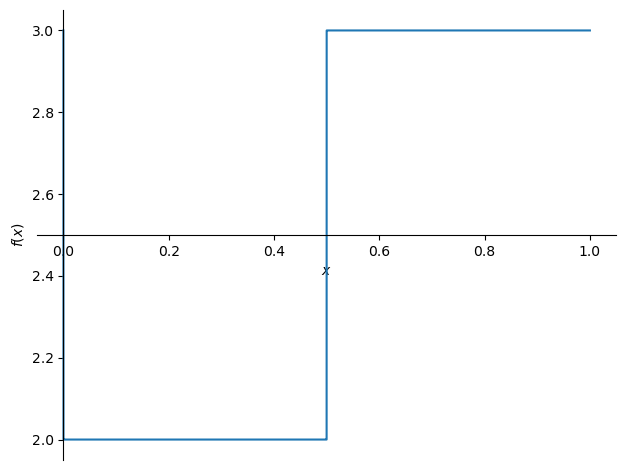

Eq((Heaviside(x, 2) + Heaviside(x - 0.5, 2) + 1)*Derivative(w(x), x), 1.0)

C1 + 1.0*Integral(1/(Heaviside(x, 2.0) + Heaviside(x - 0.5, 2.0) + 1), x)

TypeError: cannot unpack non-iterable Mul object

In [297]:
import sympy as sp
import numpy as np

w = sp.symbols('w', cls=sp.Function)
C1, C2 = sp.symbols('C1 C2')
x = sp.symbols('x')
L = 1
mean = 5.0

rng = np.random.default_rng()
F = 1.
a = 2
b = 4

E = 1+ sp.Heaviside(x, a) + sp.Heaviside(x-0.5, -a+b)

sp.plotting.plot(E,(x,0,L))

diffeq = sp.Eq(E*sp.diff(w(x),x,1), F)
display(diffeq)

w = sp.dsolve(diffeq)
w = w.rhs
display(w)

init_cond = sp.Eq(w.subs(x, 0), 0)

sol = sp.solve((init_cond),
               (C1))
w_sol = w.subs(sol)

sp.plot(w_sol,(x,0,L))

a*Piecewise((0, x < 0), (1/2, Eq(x, 0)), (1, True)) + b*Piecewise((0, x - 0.25 < 0), (1/2, Eq(x - 0.25, 0)), (1, True)) + c*Piecewise((0, x - 0.5 < 0), (1/2, Eq(x - 0.5, 0)), (1, True)) + d*Piecewise((0, x - 0.75 < 0), (1/2, Eq(x - 0.75, 0)), (1, True)) + 1

Eq((a*Piecewise((0, x < 0), (1/2, Eq(x, 0)), (1, True)) + b*Piecewise((0, x - 0.25 < 0), (1/2, Eq(x - 0.25, 0)), (1, True)) + c*Piecewise((0, x - 0.5 < 0), (1/2, Eq(x - 0.5, 0)), (1, True)) + d*Piecewise((0, x - 0.75 < 0), (1/2, Eq(x - 0.75, 0)), (1, True)) + 1)*Derivative(w(x), x), 1.0)

C1 + Piecewise((1.0*x, x < 0), (1.0*x/(1.0*a + 1.0), x < 0.25), (1.0*x/(1.0*a + 1.0*b + 1.0) - 0.25/(1.0*a + 1.0*b + 1.0) + 0.25/(1.0*a + 1.0), x < 0.5), (1.0*x/(1.0*a + 1.0*b + 1.0*c + 1.0) - 0.5/(1.0*a + 1.0*b + 1.0*c + 1.0) + 0.25/(1.0*a + 1.0*b + 1.0) + 0.25/(1.0*a + 1.0), x < 0.75), (1.0*x/(1.0*a + 1.0*b + 1.0*c + 1.0*d + 1.0) - 0.75/(1.0*a + 1.0*b + 1.0*c + 1.0*d + 1.0) + 0.25/(1.0*a + 1.0*b + 1.0*c + 1.0) + 0.25/(1.0*a + 1.0*b + 1.0) + 0.25/(1.0*a + 1.0), True))

Piecewise((0, x < 0), (-1.0*x/(1.0*a + 1.0)**2, x < 0.25), (-1.0*x/(1.0*a + 1.0*b + 1.0)**2 + 0.25/(1.0*a + 1.0*b + 1.0)**2 - 0.25/(1.0*a + 1.0)**2, x < 0.5), (-1.0*x/(1.0*a + 1.0*b + 1.0*c + 1.0)**2 + 0.5/(1.0*a + 1.0*b + 1.0*c + 1.0)**2 - 0.25/(1.0*a + 1.0*b + 1.0)**2 - 0.25/(1.0*a + 1.0)**2, x < 0.75), (-1.0*x/(1.0*a + 1.0*b + 1.0*c + 1.0*d + 1.0)**2 + 0.75/(1.0*a + 1.0*b + 1.0*c + 1.0*d + 1.0)**2 - 0.25/(1.0*a + 1.0*b + 1.0*c + 1.0)**2 - 0.25/(1.0*a + 1.0*b + 1.0)**2 - 0.25/(1.0*a + 1.0)**2, True))

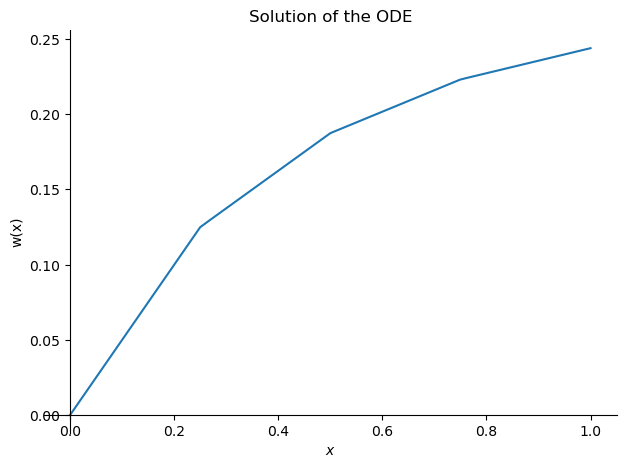

In [333]:
import sympy as sp
import numpy as np

# Define the symbols
w = sp.symbols('w', cls=sp.Function)
C1 = sp.symbols('C1')
x = sp.symbols('x')
a, b, c, d = sp.symbols('a, b, c, d')

# Define the problem parameters
L = 1

# Define the expression E
E = 1 + a*sp.Heaviside(x) + b*sp.Heaviside(x - 0.25) + c*sp.Heaviside(x - 0.5) + d*sp.Heaviside(x-0.75)
E = E.rewrite(sp.Piecewise)
display(E)
# display(E.subs((a,b),(1,2)))
# E = 1.0
# sp.plotting.plot(E.subs((a,b), (1, 2)),(x,0,L))

# Define the ODE
diffeq = sp.Eq(E * sp.diff(w(x), x), 1.0)  # Assuming F=1 as in your script
display(diffeq)

# Solve the differential equation
sol = sp.dsolve(diffeq)
w = sol.rhs
display(w)

# Define initial conditions (example: w(0) = 0)
init_cond = sp.Eq(w.subs(x, 0), 0)

# Solve for constants
constants = sp.solve(init_cond, C1)
if isinstance(constants, dict):
    w_sol = w.subs(constants)
else:
    w_sol = w.subs(C1, constants[0])

# Substitute specific values for a and b in the solution
a_val = 1
b_val = 2
c_val = 3
d_val = 5
w_sol_substituted = w_sol.subs({a: a_val, b: b_val, c: c_val, d:d_val})
display(sp.diff(w_sol, a))

# Plot the solution
sp.plot(w_sol_substituted, (x, 0, 1), title='Solution of the ODE', ylabel='w(x)')